In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

In [12]:
X_train = [[1,2],[2,3],[3,3],[6,5],[7,7]]
X_test = [[7,6]]
Y_train = [0,0,0,1,1]

In [3]:
df = pd.DataFrame(X_train)

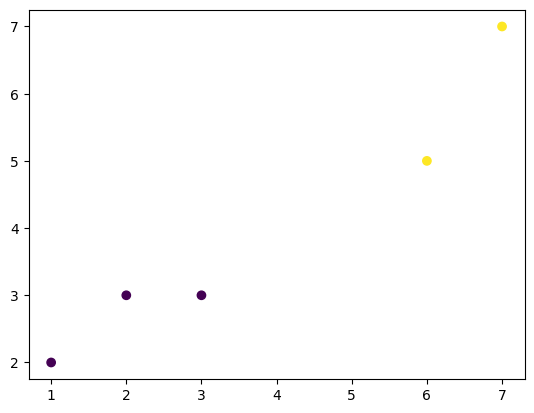

In [4]:
plt.scatter(df.iloc[:,0],df.iloc[:,1],c=Y_train)

In [5]:
class KNN:
    # Constructor of the class
    def __init__(self,k=3):
        self.k = k

    #Store the data
    def fit(self,x,y):
        self.X_train = np.array(x)
        self.Y_train = np.array(y)

    #Calculate Euclidian Distance
    def distance(self,x1,x2):
        d = np.sqrt(np.sum((x1-x2)**2))
        return(d)

    #Predict a single point
    def predict_single(self,x):
        dist = []
        for x_train in self.X_train:
            dist.append(self.distance(x,x_train))
        np.array(dist)

        #Get the index of K nearest neighbour
        k_index = np.argsort(dist)[:self.k]

        #Find the labels
        k_labels = self.Y_train[k_index]

        #Majority Count
        most_common = Counter((k_labels)).most_common(1)
        return(most_common[0][0])
        

In [13]:
knn = KNN(k=5)

In [14]:
knn.fit(X_train,Y_train)

In [15]:
knn.predict_single(X_test)

0

In [40]:
from sklearn.neighbors import KNeighborsClassifier

In [41]:
knn_skit = KNeighborsClassifier(n_neighbors=3)

In [43]:
knn_skit.fit(X_train,Y_train)

KNeighborsClassifier(n_neighbors=3)

In [44]:
knn_skit.predict(X_test)

array([1])

In [45]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

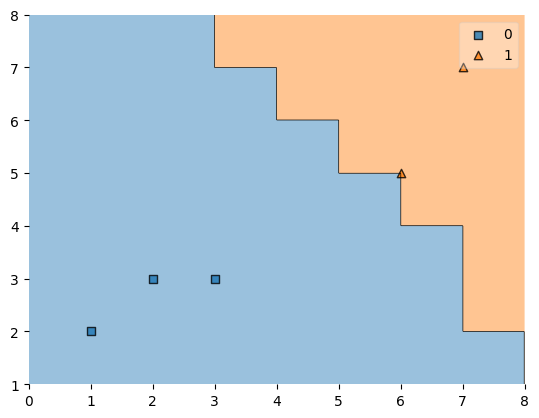

In [50]:
plot_decision_regions(np.array(X_train),np.array(Y_train),knn_skit)

In [16]:
knn.distance([1,2],[5,5])

5.0

In [20]:
np.sqrt(np.sum((np.array([1,2])-np.array([5,5]))**2))

5.0

In [22]:
arr = np.array([2,5,1,6,3,4])

In [23]:
arr.argsort()

array([2, 0, 4, 5, 1, 3], dtype=int64)

In [51]:
pwd

'C:\\Users\\arnab'

In [16]:
cd C:\Users\arnab\Documents\Python Programming\Datasets

C:\Users\arnab\Documents\Python Programming\Datasets


In [17]:
df = pd.read_csv("train.csv")

In [19]:
X = df.iloc[:,1:]
Y = df.iloc[:,0]

In [20]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,Y_train)

KNeighborsClassifier()

0.9648809523809524


(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

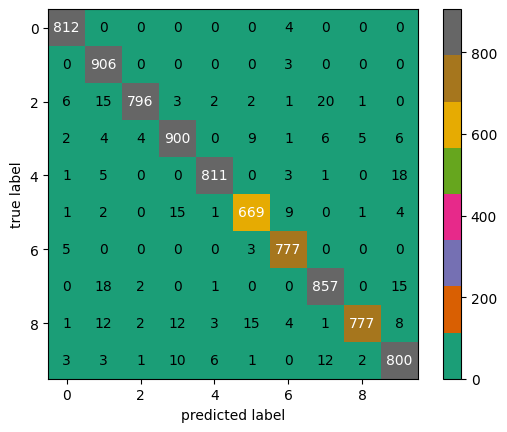

In [21]:
from sklearn.metrics import accuracy_score,confusion_matrix

acc = accuracy_score(Y_test,knn.predict(X_test))
print(acc)

from mlxtend.plotting import plot_confusion_matrix

conf = confusion_matrix(Y_test,knn.predict(X_test))

plot_confusion_matrix(conf,colorbar=True,cmap='Dark2')

In [38]:
from sklearn.preprocessing import StandardScaler

sclr = StandardScaler()

X_train = sclr.fit_transform(X_train)
X_test = sclr.transform(X_test)

from sklearn.decomposition import PCA

pca = PCA(n_components=784)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

knn.fit(X_train_pca,Y_train)

acc = accuracy_score(Y_test,knn.predict(X_test_pca))
print(acc)

0.9391666666666667


In [23]:
# How many PCA componnets we should take? According to CODE
i=1
acc_new=0
while True:
    pca=PCA(n_components=i)
    X_train_trf=pca.fit_transform(X_train)
    X_test_trf=pca.transform(X_test)
    knn.fit(X_train_trf,Y_train)
    y_pred=knn.predict(X_test_trf)
    acc=accuracy_score(Y_test,y_pred)
    if(acc_new>acc):
        break
    else:
        acc_new=acc
        i=i+1;
print(i)

In [28]:
import numpy as np

In [40]:
variance_ratio = np.cumsum(pca.explained_variance_ratio_)

In [61]:
pwd

'C:\\Users\\arnab\\Documents\\Python Programming\\Datasets'

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("winequality.csv")

In [4]:
df.dropna(inplace=True)

In [5]:
X = df.iloc[:,1:]
Y = df.iloc[:,0]

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=42,test_size=0.2)

In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
le = LabelEncoder()

In [9]:
Y = le.fit_transform(Y)

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

In [11]:
GB = GradientBoostingClassifier(learning_rate=0.08,max_depth=4,n_estimators=6)

In [12]:
GB.fit(X_train,Y_train)

GradientBoostingClassifier(learning_rate=0.08, max_depth=4, n_estimators=6)

In [13]:
from sklearn.metrics import accuracy_score

In [14]:
acc = accuracy_score(Y_test,GB.predict(X_test))

In [15]:
print(acc)

0.974477958236659


In [16]:
GB.feature_importances_

array([0.01838347, 0.02114773, 0.00066922, 0.01309252, 0.43477607,
       0.        , 0.47867075, 0.02135221, 0.00573277, 0.00617526,
       0.        , 0.        ])

In [17]:
GB.feature_names_in_

array(['fixed acidity', 'volatile acidity', 'citric acid',
       'residual sugar', 'chlorides', 'free sulfur dioxide',
       'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol',
       'quality'], dtype=object)

In [18]:
df = pd.DataFrame(GB.feature_importances_)

In [25]:
df = df.T

In [32]:
df.columns = GB.feature_names_in_

In [34]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.018383,0.021148,0.000669,0.013093,0.434776,0.0,0.478671,0.021352,0.005733,0.006175,0.0,0.0


In [35]:
from sklearn.decomposition import PCA

In [36]:
pca = PCA(n_components=8)

In [37]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [38]:
GB.fit(X_train_pca,Y_train)

GradientBoostingClassifier(learning_rate=0.08, max_depth=4, n_estimators=6)

In [39]:
acc = accuracy_score(Y_test,GB.predict(X_test_pca))

In [41]:
print(acc)

0.9450889404485692


In [42]:
GB.feature_importances_

array([7.98208790e-01, 9.86096767e-03, 7.55762855e-03, 5.10585373e-02,
       4.05513475e-03, 1.79107606e-17, 1.29258942e-01, 0.00000000e+00])